# Download the file

In [1]:
import pandas as  pd
final_ml_df = pd.read_csv(r"F:\downloads microsodt\GSE108966_EST_RIF_ml_dataset.csv") 
#Use raw string r"..." for Windows paths so backslashes are handled correctly.

final_ml_df = final_ml_df[final_ml_df["Tissue"].str.strip().str.lower() == "endometrium"]

display(final_ml_df.head(5))
print("shape of the df:", final_ml_df.shape)
print("df info:")
final_ml_df.info()

,Sample,GSM_ID,Tissue,Patient_ID,LH_Day,Condition,hsa-let-7a-3p,hsa-let-7a-5p,hsa-let-7a-2-3p,hsa-let-7b-5p,...,hsa-miR-95-5p,hsa-miR-95-3p,hsa-miR-96-5p,hsa-miR-96-3p,hsa-miR-98-3p,hsa-miR-98-5p,hsa-miR-99a-3p,hsa-miR-99a-5p,hsa-miR-99b-5p,hsa-miR-99b-3p
0,ERTK11LH2E,GSM2916612,endometrium,ERTK11,2,CONTROL,375,210095,0,10134,...,6,30,782,0,33,15744,118,4998,16907,51
1,ERTK11LH8E,GSM2916613,endometrium,ERTK11,8,CONTROL,1091,279622,2,25660,...,12,85,1345,1,176,14554,309,7993,21134,274
3,NOT1209LH2E,GSM2916615,endometrium,NOT1209,2,CONTROL,319,174320,1,13416,...,1,44,881,0,37,6129,260,15459,22034,187
5,NOT1209LH8E,GSM2916617,endometrium,NOT1209,8,CONTROL,1034,232909,1,21021,...,4,62,1732,0,139,13073,322,12973,24847,218
7,NOT1210LH2E,GSM2916619,endometrium,NOT1210,2,CONTROL,583,204129,0,12338,...,4,60,1033,2,57,10545,252,9703,13694,147


shape of the df: (64, 2594)
df info:
<class 'pandas.DataFrame'>
Index: 64 entries, 0 to 110
Columns: 2594 entries, Sample to hsa-miR-99b-3p
dtypes: int64(2589), str(5)
memory usage: 1.3 MB


# ML workflow - dataset cleaning and filter

In [2]:
final_ml_df = final_ml_df.copy()
final_ml_df['Label'] = final_ml_df['Condition'].map({
    'CONTROL': 0,
    'IVF': 1
})

print(final_ml_df[['Condition', 'Label']].head())
print(final_ml_df["Label"].value_counts())


  Condition  Label
0   CONTROL      0
1   CONTROL      0
3   CONTROL      0
5   CONTROL      0
7   CONTROL      0
Label
0    44
1    20
Name: count, dtype: int64


In [3]:
metadata_cols = [
    'Sample',
    'GSM_ID',
    'Tissue',
    'Patient_ID',
    'LH_Day',
    'Condition',
    'Label'
]

X = final_ml_df.drop(columns=metadata_cols)

y = final_ml_df['Label']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (64, 2588)
y shape: (64,)


In [4]:
print("Missing values in X:", X.isnull().sum().sum())

print("Missing values in y:", y.isnull().sum())

Missing values in X: 0
Missing values in y: 0


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\ny_train distribution:")
print(y_train.value_counts())

print("\ny_test distribution:")
print(y_test.value_counts())

X_train: (51, 2588)
X_test: (13, 2588)

y_train distribution:
Label
0    35
1    16
Name: count, dtype: int64

y_test distribution:
Label
0    9
1    4
Name: count, dtype: int64


In [6]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)

selector = VarianceThreshold(threshold=0.01)

X_train_var = selector.fit_transform(X_train)
X_test_var = selector.transform(X_test)


print("Original shape:", X_train.shape)
print("After variance filtering:", X_train_var.shape)


print("Original shape:", X_test.shape)
print("After variance filtering:", X_test_var.shape)

Original shape: (51, 2588)
After variance filtering: (51, 1990)
Original shape: (13, 2588)
After variance filtering: (13, 1990)


In [7]:
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()

X_train_scale = scaler.fit_transform(X_train_var)
X_test_scale = scaler.transform(X_test_var)

print(X_train_scale.shape)
print(X_test_scale.shape)


(51, 1990)
(13, 1990)


In [8]:
from sklearn.feature_selection import SelectKBest, f_classif

selector_kbest = SelectKBest(score_func=f_classif, k=50)

X_train_selected = selector_kbest.fit_transform(X_train_scale, y_train)

X_test_selected = selector_kbest.transform(X_test_scale)

print("X_train_selected:", X_train_selected.shape)
print("X_test_selected:", X_test_selected.shape)

X_train_selected: (51, 50)
X_test_selected: (13, 50)


# Model building #1

In [9]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train_selected)

# Transform test data
X_test_scaled = scaler.transform(X_test_selected)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(51, 50)
(13, 50)


In [10]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Create SVM model
svm_model = SVC(
    kernel='linear',
    class_weight='balanced',
    random_state=42
)

# Train
svm_model.fit(X_train_scaled, y_train)

# Predict
y_pred_svm = svm_model.predict(X_test_scaled)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_svm))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_svm))

Accuracy: 0.8461538461538461

Classification Report:

              precision    recall  f1-score   support

           0       0.82      1.00      0.90         9
           1       1.00      0.50      0.67         4

    accuracy                           0.85        13
   macro avg       0.91      0.75      0.78        13
weighted avg       0.87      0.85      0.83        13


Confusion Matrix:

[[9 0]
 [2 2]]


In [11]:
import pandas as pd
import numpy as np

# Get feature importance from linear SVM
importance = np.abs(svm_model.coef_[0])

# Get the feature names that passed the VarianceThreshold
features_after_variance = X.columns[selector.get_support()]

# Get the names of the top K features selected by SelectKBest
selected_features = features_after_variance[selector_kbest.get_support()]

# Create dataframe
feature_importance_df = pd.DataFrame({
    'miRNA': selected_features,
    'Importance': importance
})

# Sort descending
feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Top 20 biomarkers
top20 = feature_importance_df.head(20)

display(top20)

,miRNA,Importance
49,hsa-miR-95-3p,0.305162
41,hsa-miR-5696,0.265179
30,hsa-miR-378g,0.262722
26,hsa-miR-3607-5p,0.228492
10,hsa-miR-2114-3p,0.226323
48,hsa-miR-934,0.214395
31,hsa-miR-431-5p,0.193063
20,hsa-miR-31-3p,0.168565
3,hsa-miR-1307-5p,0.167649
5,hsa-miR-141-3p,0.156159


In [12]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Stratified K-Fold
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Cross-validation accuracy
cv_scores = cross_val_score(
    svm_model,
    X_train_scaled,
    y_train,
    cv=skf,
    scoring='accuracy'
)

print("Cross-validation scores:")
print(cv_scores)

print("\nMean CV Accuracy:")
print(cv_scores.mean())

print("\nStandard Deviation:")
print(cv_scores.std())

Cross-validation scores:
[0.90909091 1.         1.         0.9        1.        ]

Mean CV Accuracy:
0.9618181818181817

Standard Deviation:
0.04685126809718228


AUC Score: 1.0


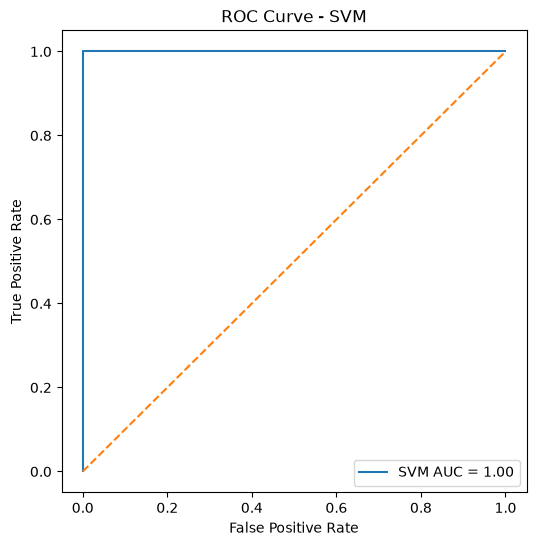

In [13]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probability-like scores
y_scores = svm_model.decision_function(X_test_scaled)

# ROC
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

# AUC
roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

# Plot
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"SVM AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend()

plt.show()

In [14]:


import shap
import numpy as np

# Create explainer
explainer = shap.LinearExplainer(
    svm_model,
    X_train_scaled
)

# SHAP values
shap_values = explainer.shap_values(X_test_scaled)

print(np.array(shap_values).shape)

c:\Users\LENOVO\anaconda3\envs\biomarker\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(13, 50)


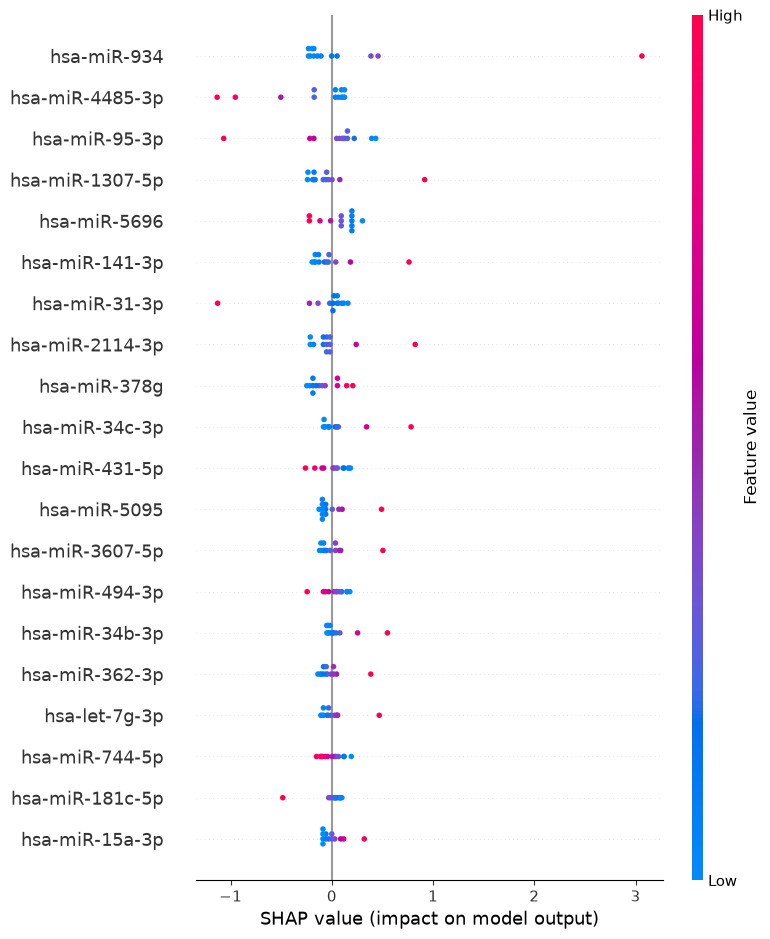

In [15]:
import matplotlib.pyplot as plt

# Summary plot
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=selected_features
)

In [16]:
# Mean absolute SHAP importance
shap_importance = np.abs(shap_values).mean(axis=0)

# Create dataframe
shap_df = pd.DataFrame({
    'miRNA': selected_features,
    'SHAP_Importance': shap_importance
})

# Sort
shap_df = shap_df.sort_values(
    by='SHAP_Importance',
    ascending=False
)

# Top biomarkers
display(shap_df.head(20))

,miRNA,SHAP_Importance
48,hsa-miR-934,0.417963
33,hsa-miR-4485-3p,0.278945
49,hsa-miR-95-3p,0.252767
3,hsa-miR-1307-5p,0.185644
41,hsa-miR-5696,0.164863
5,hsa-miR-141-3p,0.163232
20,hsa-miR-31-3p,0.160842
10,hsa-miR-2114-3p,0.157690
30,hsa-miR-378g,0.148872
24,hsa-miR-34c-3p,0.131995


# Model building #2

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Logistic Regression model
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=5000,
    random_state=42
)

# Train
lr_model.fit(X_train_scaled, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test_scaled)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_lr))

Accuracy: 0.9230769230769231

Classification Report:

              precision    recall  f1-score   support

           0       0.90      1.00      0.95         9
           1       1.00      0.75      0.86         4

    accuracy                           0.92        13
   macro avg       0.95      0.88      0.90        13
weighted avg       0.93      0.92      0.92        13


Confusion Matrix:

[[9 0]
 [1 3]]


In [18]:
from sklearn.model_selection import cross_val_score

# Cross-validation
lr_cv_scores = cross_val_score(
    lr_model,
    X_train_scaled,
    y_train,
    cv=skf,
    scoring='accuracy'
)

print("CV Scores:")
print(lr_cv_scores)

print("\nMean CV Accuracy:")
print(lr_cv_scores.mean())

print("\nSTD:")
print(lr_cv_scores.std())

CV Scores:
[0.90909091 0.9        0.9        0.9        1.        ]

Mean CV Accuracy:
0.9218181818181819

STD:
0.03924915117258709


Logistic Regression AUC: 0.9722222222222222


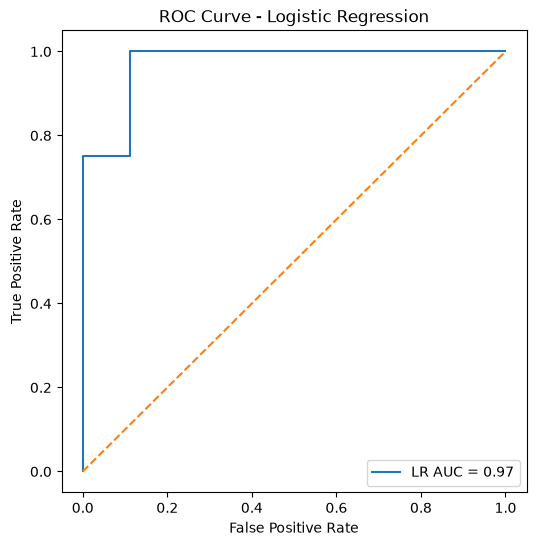

In [19]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probability scores
y_scores_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# ROC
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_scores_lr)

# AUC
roc_auc_lr = auc(fpr_lr, tpr_lr)

print("Logistic Regression AUC:", roc_auc_lr)

# Plot
plt.figure(figsize=(6,6))

plt.plot(fpr_lr, tpr_lr,
         label=f"LR AUC = {roc_auc_lr:.2f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()

In [20]:
import numpy as np
import pandas as pd

# Coefficient importance
lr_importance = np.abs(lr_model.coef_[0])

# Create dataframe
lr_biomarkers = pd.DataFrame({
    'miRNA': selected_features,
    'Coefficient_Importance': lr_importance
})

# Sort
lr_biomarkers = lr_biomarkers.sort_values(
    by='Coefficient_Importance',
    ascending=False
)

# Top biomarkers
display(lr_biomarkers.head(20))


,miRNA,Coefficient_Importance
49,hsa-miR-95-3p,0.721139
26,hsa-miR-3607-5p,0.641667
48,hsa-miR-934,0.616315
10,hsa-miR-2114-3p,0.615280
30,hsa-miR-378g,0.543029
41,hsa-miR-5696,0.527786
31,hsa-miR-431-5p,0.496340
45,hsa-miR-744-5p,0.362066
35,hsa-miR-494-3p,0.358389
38,hsa-miR-5095,0.356895


In [21]:
import shap
import numpy as np

# Explainer
lr_explainer = shap.LinearExplainer(
    lr_model,
    X_train_scaled
)

# SHAP values
lr_shap_values = lr_explainer.shap_values(X_test_scaled)

print(np.array(lr_shap_values).shape)

(13, 50)


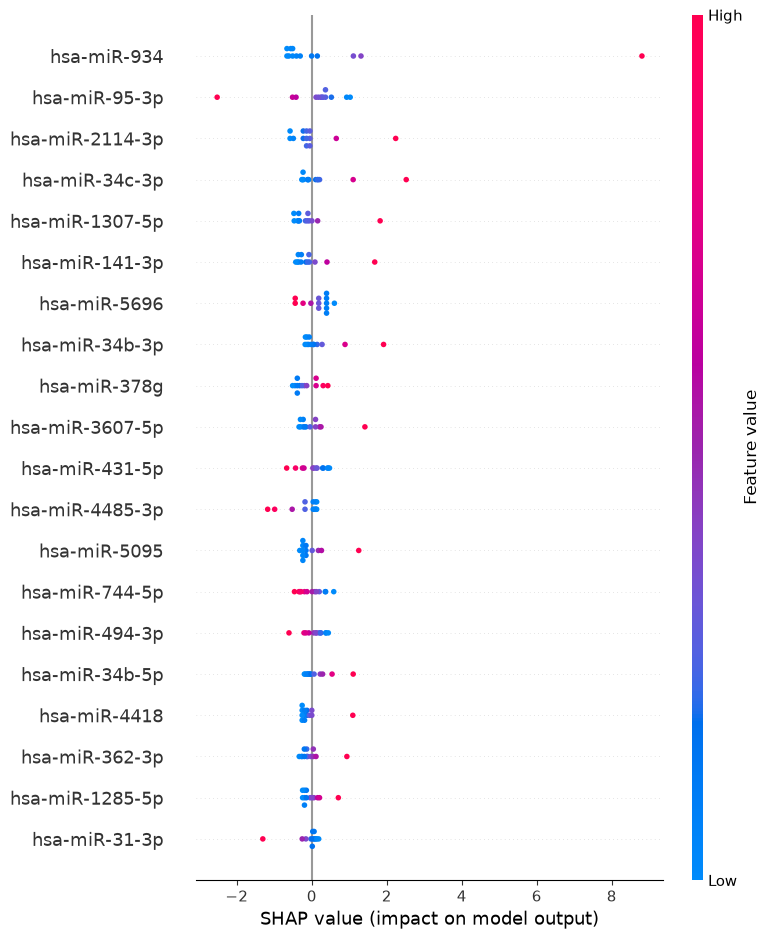

In [22]:
import matplotlib.pyplot as plt

# SHAP summary plot
shap.summary_plot(
    lr_shap_values,
    X_test_scaled,
    feature_names=selected_features
)

In [23]:
# Mean absolute SHAP importance
lr_shap_importance = np.abs(lr_shap_values).mean(axis=0)

# DataFrame
lr_shap_df = pd.DataFrame({
    'miRNA': selected_features,
    'SHAP_Importance': lr_shap_importance
})

# Sort
lr_shap_df = lr_shap_df.sort_values(
    by='SHAP_Importance',
    ascending=False
)

# Display top biomarkers
display(lr_shap_df.head(20))



,miRNA,SHAP_Importance
48,hsa-miR-934,1.201504
49,hsa-miR-95-3p,0.597323
10,hsa-miR-2114-3p,0.428694
24,hsa-miR-34c-3p,0.424751
3,hsa-miR-1307-5p,0.368950
5,hsa-miR-141-3p,0.359395
41,hsa-miR-5696,0.328127
22,hsa-miR-34b-3p,0.314296
30,hsa-miR-378g,0.307709
26,hsa-miR-3607-5p,0.297977


#comparison of models

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract metrics for SVM
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_report = classification_report(y_test, y_pred_svm, output_dict=True)
svm_precision = svm_report['macro avg']['precision']
svm_recall = svm_report['macro avg']['recall']
svm_f1 = svm_report['macro avg']['f1-score']
# roc_auc for SVM is roc_auc from cell vQ16YF6OQgZ5
svm_auc = roc_auc
# Mean CV Accuracy for SVM is cv_scores.mean() from cell 21DUFM5dQUib
svm_cv_mean_accuracy = cv_scores.mean()

# Extract metrics for Logistic Regression
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_report = classification_report(y_test, y_pred_lr, output_dict=True)
lr_precision = lr_report['macro avg']['precision']
lr_recall = lr_report['macro avg']['recall']
lr_f1 = lr_report['macro avg']['f1-score']
# roc_auc_lr for Logistic Regression is roc_auc_lr from cell CjqPIuIkR_lM
lr_auc = roc_auc_lr
# Mean CV Accuracy for Logistic Regression is lr_cv_scores.mean() from cell iIUREe42R2S6
lr_cv_mean_accuracy = lr_cv_scores.mean()

# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy (Test Set)', 'Precision (Macro Avg)', 'Recall (Macro Avg)', 'F1-score (Macro Avg)', 'AUC (Test Set)', '5-fold CV Mean Accuracy'],
    'SVM': [
        f'{svm_accuracy:.2f}',
        f'{svm_precision:.2f}',
        f'{svm_recall:.2f}',
        f'{svm_f1:.2f}',
        f'{svm_auc:.2f}',
        f'{svm_cv_mean_accuracy:.2f}'
    ],
    'Logistic Regression': [
        f'{lr_accuracy:.2f}',
        f'{lr_precision:.2f}',
        f'{lr_recall:.2f}',
        f'{lr_f1:.2f}',
        f'{lr_auc:.2f}',
        f'{lr_cv_mean_accuracy:.2f}'
    ]
})

display(comparison_df)

# Visualize the table as an image for a research paper
fig, ax = plt.subplots(figsize=(10, 4)) # Adjust size as needed
ax.axis('off') # Hide axes

# Create the table
table = ax.table(
    cellText=comparison_df.values,
    colLabels=comparison_df.columns,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2) # Scale for better readability

ax.set_title('Model Performance Comparison', fontsize=16, pad=20)

plt.tight_layout()
plt.close()



,Metric,SVM,Logistic Regression
0,Accuracy (Test Set),0.85,0.92
1,Precision (Macro Avg),0.91,0.95
2,Recall (Macro Avg),0.75,0.88
3,F1-score (Macro Avg),0.78,0.90
4,AUC (Test Set),1.00,0.97
5,5-fold CV Mean Accuracy,0.96,0.92


In [25]:
comparison_df1 = comparison_df.T
display(comparison_df1)


,0,1,2,3,4,5
Metric,Accuracy (Test Set),Precision (Macro Avg),Recall (Macro Avg),F1-score (Macro Avg),AUC (Test Set),5-fold CV Mean Accuracy
SVM,0.85,0.91,0.75,0.78,1.00,0.96
Logistic Regression,0.92,0.95,0.88,0.90,0.97,0.92


# comparision of biomarkers

In [26]:
# Top 20 from each method

svm_top = set(feature_importance_df.head(20)['miRNA'])

svm_shap_top = set(shap_df.head(20)['miRNA'])

lr_top = set(lr_biomarkers.head(20)['miRNA'])

lr_shap_top = set(lr_shap_df.head(20)['miRNA'])

print("Done")

Done


In [27]:
# Find consensus biomarkers

consensus = (
    svm_top &
    svm_shap_top &
    lr_top &
    lr_shap_top
)

print("Consensus Biomarkers:\n")
print(consensus)

print("\nNumber of consensus biomarkers:")
print(len(consensus))

Consensus Biomarkers:

{'hsa-miR-934', 'hsa-miR-494-3p', 'hsa-miR-95-3p', 'hsa-miR-141-3p', 'hsa-miR-362-3p', 'hsa-miR-744-5p', 'hsa-miR-3607-5p', 'hsa-miR-378g', 'hsa-miR-5696', 'hsa-miR-2114-3p', 'hsa-miR-5095', 'hsa-miR-1307-5p', 'hsa-miR-431-5p'}

Number of consensus biomarkers:
13


In [28]:
# Convert to dataframe
consensus_df = pd.DataFrame({
    'Consensus_miRNA': list(consensus)
})

display(consensus_df)



,Consensus_miRNA
0,hsa-miR-934
1,hsa-miR-494-3p
2,hsa-miR-95-3p
3,hsa-miR-141-3p
4,hsa-miR-362-3p
5,hsa-miR-744-5p
6,hsa-miR-3607-5p
7,hsa-miR-378g
8,hsa-miR-5696
9,hsa-miR-2114-3p


# evaluation with deSeq

In [29]:
res = pd.read_csv(r"F:\downloads microsodt\DESeq2_results.csv")

display(res.head(5))
display(res.shape)

,Unnamed: 0,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,hsa.miR.4485.3p,262.395421,6.367132,0.535257,11.895458,1.249663e-32,1.665800e-29
1,hsa.miR.5701,83.148010,1.796157,0.220865,8.132365,4.209939e-16,2.805924e-13
2,hsa.miR.5585.3p,24.489868,3.449230,0.437013,7.892731,2.956433e-15,1.313642e-12
3,hsa.miR.4484,3.453891,3.358624,0.442776,7.585381,3.315115e-14,1.104762e-11
4,hsa.miR.4284,5.940096,4.813253,0.655746,7.340118,2.134062e-13,5.689410e-11


(2588, 7)

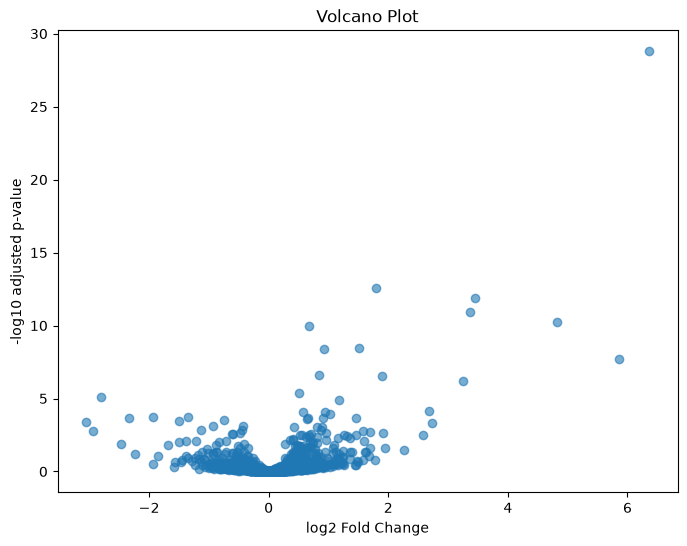

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

res = pd.read_csv(r"F:\downloads microsodt\DESeq2_results.csv")

plt.figure(figsize=(8,6))

plt.scatter(
    res["log2FoldChange"],
    -np.log10(res["padj"]),
    alpha=0.6
)

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10 adjusted p-value")
plt.title("Volcano Plot")

plt.show()

In [31]:
sig = res[
    (res["padj"] < 0.05) &
    (abs(res["log2FoldChange"]) > 1)
]

sig_mirnas = sig['Unnamed: 0'].tolist()

print(len(sig_mirnas))

50


In [32]:
# 1. DESeq2 significant miRNAs (already available from previous steps)
deseq2_mirnas = set([mirna.replace('.', '-') for mirna in sig_mirnas])

In [33]:
common_mirnas = consensus.intersection(deseq2_mirnas)

print("Common miRNAs between consensus and DESeq2:")
print(common_mirnas)
print(f"Number of common miRNAs: {len(common_mirnas)}")

Common miRNAs between consensus and DESeq2:
{'hsa-miR-934', 'hsa-miR-3607-5p', 'hsa-miR-362-3p'}
Number of common miRNAs: 3


In [34]:
res_cleaned = res.copy()
res_cleaned['cleaned_mirna_name'] = res_cleaned['Unnamed: 0'].str.replace('.', '-', regex=False)

final_biomarkers_df = res_cleaned[res_cleaned['cleaned_mirna_name'].isin(common_mirnas)].set_index('Unnamed: 0')
print("DESeq2 values for Final Biomarkers:")
display(final_biomarkers_df)

DESeq2 values for Final Biomarkers:


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,cleaned_mirna_name
Unnamed: 0,,,,,,,
hsa.miR.3607.5p,10.122258,-3.058100,0.687344,-4.449158,0.000009,0.000396,hsa-miR-3607-5p
hsa.miR.934,7.259396,2.580431,0.669591,3.853741,0.000116,0.003016,hsa-miR-934
hsa.miR.362.3p,30.797038,1.151878,0.313855,3.670097,0.000242,0.005478,hsa-miR-362-3p


## volcano plot

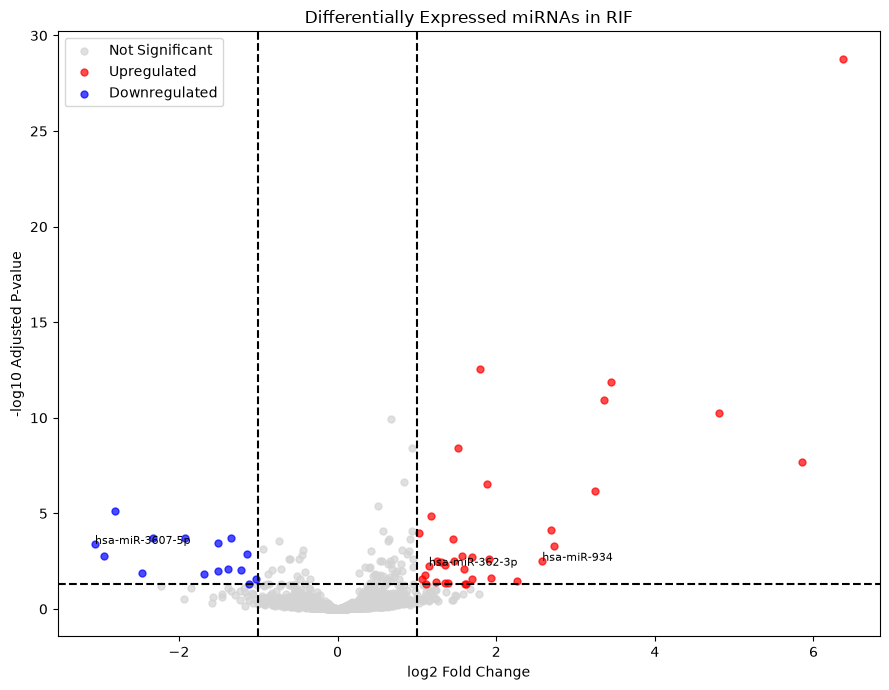

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

res = pd.read_csv(r"F:\downloads microsodt\DESeq2_results.csv")

# Rename 'Unnamed: 0' column to 'miRNA Name' for clarity and consistency
res = res.rename(columns={'Unnamed: 0': 'miRNA Name'})
# Clean miRNA names by replacing '.' with '-' to match the 'important' list format
res['miRNA Name'] = res['miRNA Name'].str.replace('.', '-', regex=False)

res["group"] = "Not Significant"

res.loc[
    (res["padj"] < 0.05) &
    (res["log2FoldChange"] > 1),
    "group"
] = "Upregulated"

res.loc[
    (res["padj"] < 0.05) &
    (res["log2FoldChange"] < -1),
    "group"
] = "Downregulated"

colors = {
    "Not Significant":"lightgray",
    "Upregulated":"red",
    "Downregulated":"blue"
}

plt.figure(figsize=(9,7))

for group, color in colors.items():
    subset = res[res["group"] == group]

    plt.scatter(
        subset["log2FoldChange"],
        -np.log10(subset["padj"]),
        c=color,
        s=25,
        alpha=0.7,
        label=group
    )

plt.axhline(-np.log10(0.05),
            linestyle='--',
            color='black')

plt.axvline(1,
            linestyle='--',
            color='black')

plt.axvline(-1,
            linestyle='--',
            color='black')

important = common_mirnas

for _, row in res.iterrows():
    # Check if the miRNA name (now cleaned) is in the important list
    if row["miRNA Name"] in important:

        plt.text(
            row["log2FoldChange"],
            -np.log10(row["padj"]),
            row["miRNA Name"],
            fontsize=8
        )

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10 Adjusted P-value")
plt.title("Differentially Expressed miRNAs in RIF")
plt.legend()
plt.tight_layout()
plt.show()

## heat map

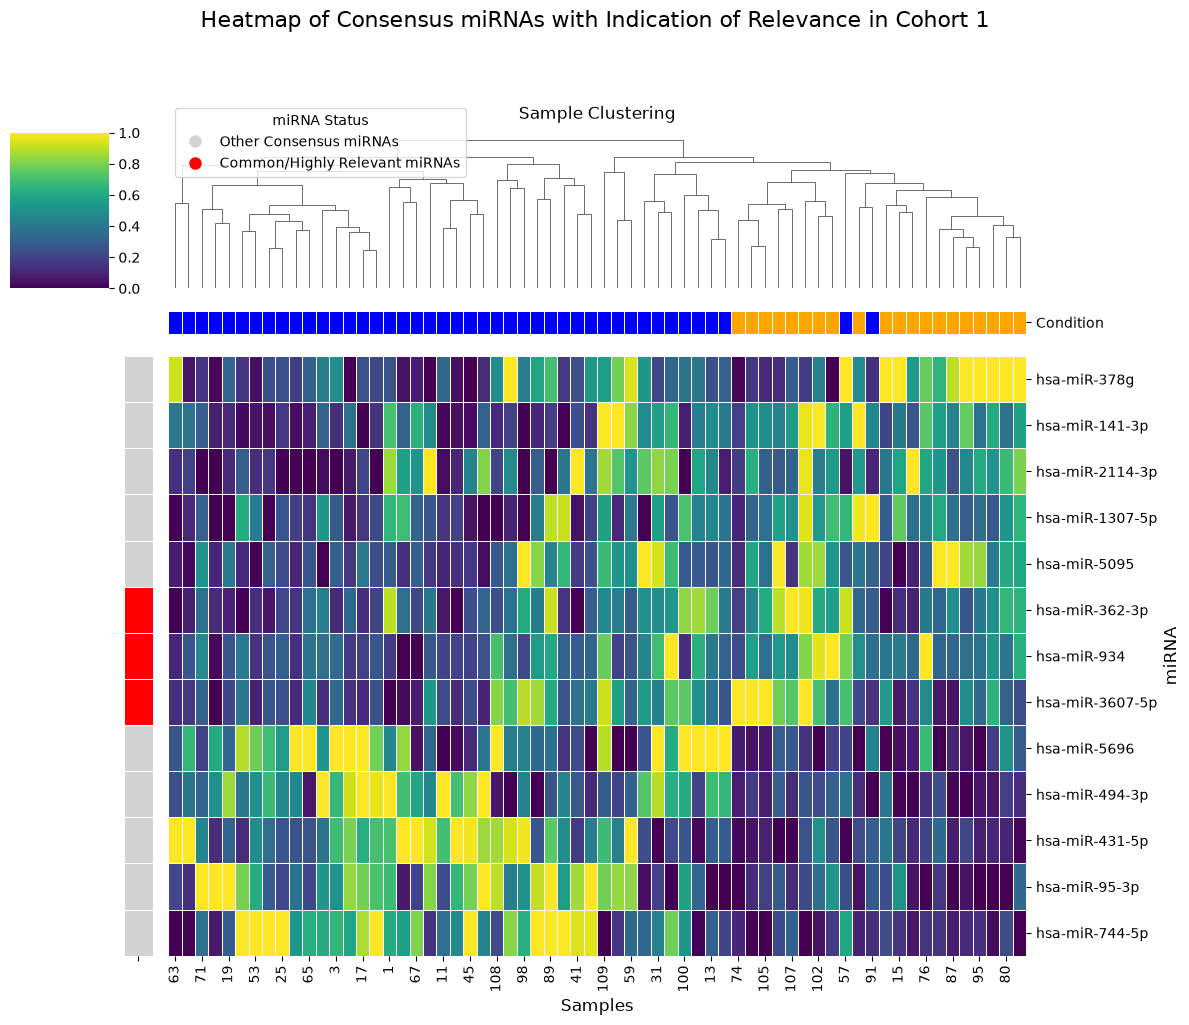

Heatmap of consensus miRNAs with relevance indication and sample conditions saved as 'consensus_mirna_heatmap_relevant_with_conditions.png'


In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Get the list of consensus miRNAs from the 'consensus' set
consensus_mirnas_list = list(consensus)

# Filter the original feature DataFrame (X) to include only consensus miRNAs
# Ensure column names in X match the format in consensus_mirnas_list
# X.columns are already in the correct format (e.g., 'hsa-miR-4478')
heatmap_data = X[consensus_mirnas_list]

# Prepare column annotations for sample conditions (RIF vs. Control)
# Get the 'Condition' from the original final_ml_df for samples corresponding to X
sample_conditions = final_ml_df.set_index(X.index).loc[heatmap_data.index, 'Condition']

# Create a color mapping for conditions
condition_colors_map = {'CONTROL': 'blue', 'IVF': 'orange'}
col_colors = sample_conditions.map(condition_colors_map)

# Create a color map for row annotations (since miRNAs will be rows after transposing)
# Common miRNAs (from DESeq2 integration) will be highlighted as most relevant
row_colors = pd.Series('lightgrey', index=heatmap_data.columns)

# 'common_mirnas' is already defined from previous steps as the intersection of consensus and DESeq2 significant miRNAs
for mirna in common_mirnas:
    if mirna in row_colors.index:
        row_colors[mirna] = 'red'

# Standardize the data (important for heatmaps, especially when comparing expression levels)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_heatmap_data = pd.DataFrame(scaler.fit_transform(heatmap_data), columns=heatmap_data.columns, index=heatmap_data.index)

# Generate the heatmap using seaborn.clustermap for hierarchical clustering
# This provides a comprehensive visualization suitable for research papers
g = sns.clustermap(
    scaled_heatmap_data.T, # Transpose to have miRNAs as rows and samples as columns
    cmap='viridis', # A perceptually uniform colormap
    standard_scale=1, # Standardize across features (miRNAs)
    figsize=(12, 10), # Adjust figure size for publication quality
    row_colors=row_colors, # Apply the highlighting colors to rows (miRNAs)
    col_colors=col_colors, # Apply colors to columns (samples) based on condition
    dendrogram_ratio=(0.1, 0.2), # Adjust dendrogram sizes
    cbar_pos=(0.02, 0.8, 0.03, 0.15), # Position of the color bar (left, bottom, width, height)
    linewidths=0.5, # Add lines between cells
    linecolor='white'
)

# Customize the plot for research paper quality
g.ax_row_dendrogram.set_visible(False) # Hide row dendrogram if not critical for interpretation
g.ax_col_dendrogram.set_title('Sample Clustering', fontsize=12, pad=10) # Title for sample dendrogram
g.ax_heatmap.set_ylabel('miRNA', fontsize=12)
g.ax_heatmap.set_xlabel('Samples', fontsize=12)

# Rotate miRNA labels for readability
g.ax_heatmap.tick_params(axis='y', rotation=0)

# Add a title to the entire figure
g.fig.suptitle('Heatmap of Consensus miRNAs with Indication of Relevance in Cohort 1', y=1.02, fontsize=16)

# Create a legend for the row colors (miRNA relevance)
highlight_patches = [
    plt.Line2D([0], [0], marker='o', color='w', label='Other Consensus miRNAs', markerfacecolor='lightgrey', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Common/Highly Relevant miRNAs', markerfacecolor='red', markersize=10)
]
# Create a legend for the column colors (sample conditions)
condition_patches = [
    plt.Line2D([0], [0], marker='s', color='w', label='CONTROL Samples', markerfacecolor=condition_colors_map['CONTROL'], markersize=10),
    plt.Line2D([0], [0], marker='s', color='w', label='IVF Samples', markerfacecolor=condition_colors_map['IVF'], markersize=10)
]

# Position the legends
g.ax_col_dendrogram.legend(handles=highlight_patches, loc='upper left', bbox_to_anchor=(0, 1.2), fontsize=10, title='miRNA Status')
g.ax_row_dendrogram.legend(handles=condition_patches, loc='upper left', bbox_to_anchor=(0, 1.2), fontsize=10, title='Sample Condition') # Adjusted to ax_row_dendrogram for sample legend

plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent title overlap

# Save the plot as a high-resolution PNG image
plt.show()

print("Heatmap of consensus miRNAs with relevance indication and sample conditions saved as 'consensus_mirna_heatmap_relevant_with_conditions.png'")

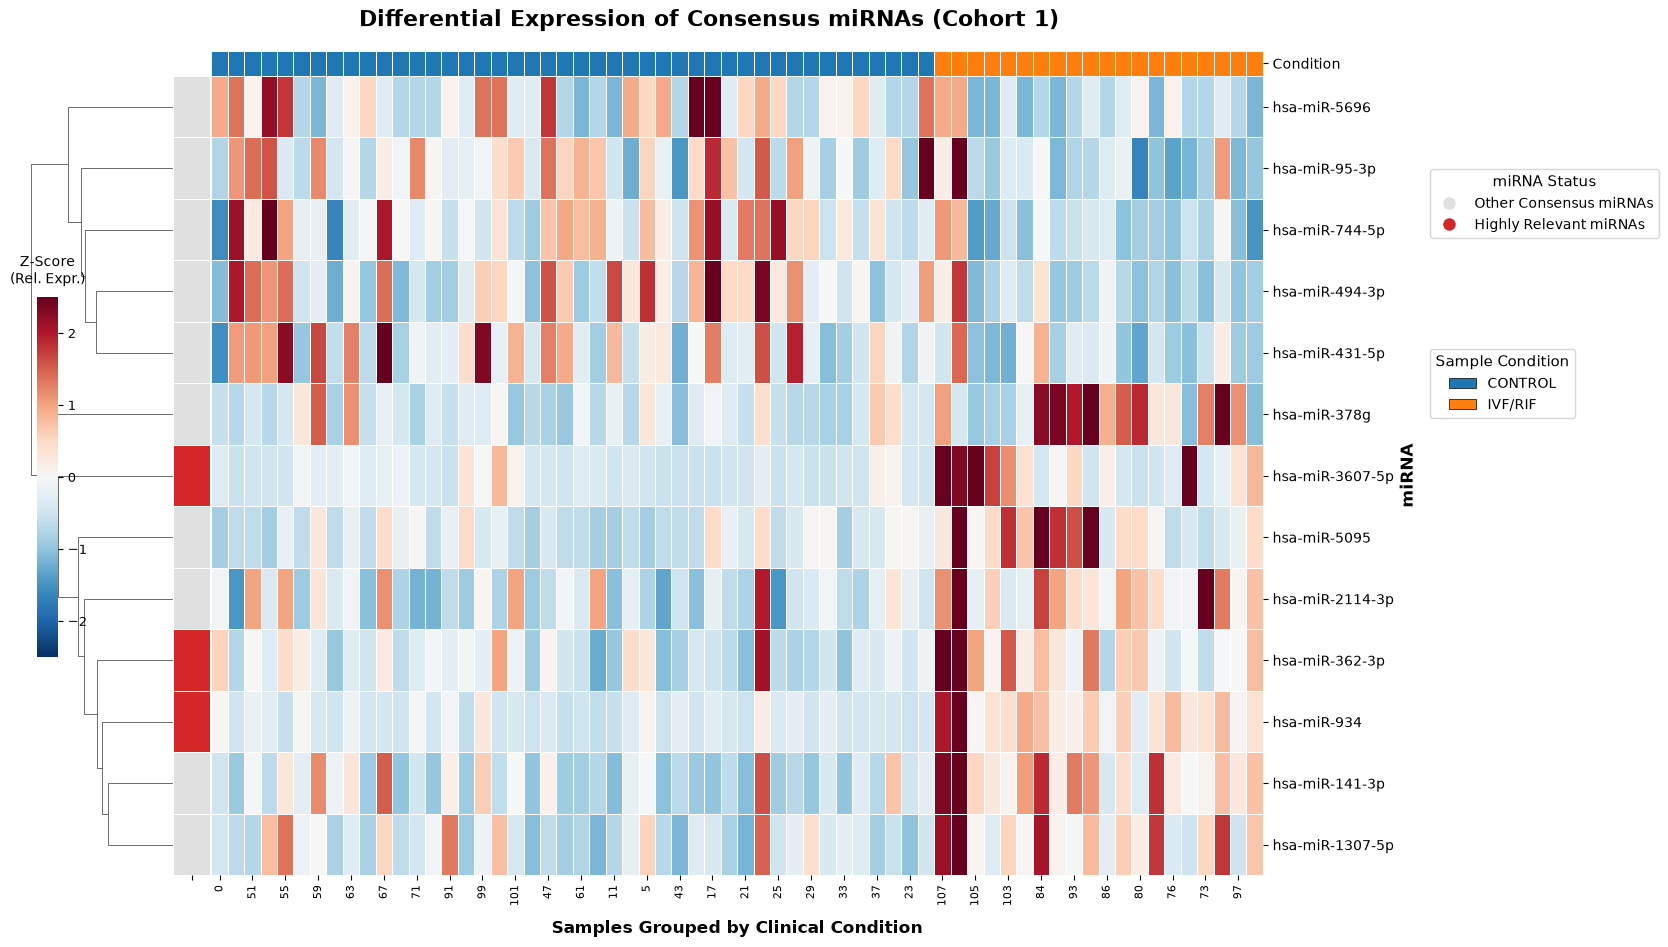

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# 1. Prepare and Sort the Data (Same as before)
consensus_mirnas_list = list(consensus)
heatmap_data = X[consensus_mirnas_list].copy()

heatmap_data['Condition'] = final_ml_df.set_index(X.index).loc[heatmap_data.index, 'Condition']
heatmap_data = heatmap_data.sort_values(by='Condition')

sample_conditions = heatmap_data['Condition']
heatmap_data = heatmap_data.drop(columns=['Condition'])

# Color mapping for samples
condition_colors_map = {'CONTROL': '#1f77b4', 'IVF': '#ff7f0e'} # Using standard muted hex colors for pub
col_colors = sample_conditions.map(condition_colors_map)

# Color mapping for key miRNAs
row_colors = pd.Series('#e0e0e0', index=heatmap_data.columns) # Light grey hex
for mirna in common_mirnas:
    if mirna in row_colors.index:
        row_colors[mirna] = '#d62728' # Deep red hex

# 2. Generate the Clustermap with Fixed Grid Spacing
g = sns.clustermap(
    heatmap_data.T,
    cmap='RdBu_r',
    z_score=0,
    center=0,
    col_cluster=False,
    row_cluster=True,
    figsize=(14, 9),              # CHANGED: Wider, shorter aspect ratio fits this data better
    row_colors=row_colors,
    col_colors=col_colors,
    dendrogram_ratio=(0.12, 0.01),# CHANGED: Shrinks the empty top space to 1%, fixing the massive gap
    colors_ratio=0.03,            # CHANGED: Makes the annotation color bars thinner and more elegant
    cbar_pos=(0.02, 0.3, 0.015, 0.4), # CHANGED: Places the colorbar cleanly on the middle-left
    linewidths=0.5,
    linecolor='white',
    vmin=-2.5, vmax=2.5
)

# 3. Clean up the Aesthetics for Publication
# Hide the practically empty column dendrogram axis completely
g.ax_col_dendrogram.set_visible(False)

# Format the Colorbar (Z-score)
g.ax_cbar.set_title('Z-Score\n(Rel. Expr.)', fontsize=10, pad=10)
g.ax_cbar.tick_params(labelsize=9)

# Format the Main Axes
g.ax_heatmap.set_ylabel('miRNA', fontsize=12, fontweight='bold')
g.ax_heatmap.set_xlabel('Samples Grouped by Clinical Condition', fontsize=12, fontweight='bold', labelpad=10)
g.ax_heatmap.tick_params(axis='y', rotation=0, labelsize=10)
g.ax_heatmap.tick_params(axis='x', rotation=90, labelsize=8) # Rotate sample IDs to prevent overlapping

# Main Title
g.fig.suptitle('Differential Expression of Consensus miRNAs (Cohort 1)', y=1.02, fontsize=16, fontweight='bold')

# 4. Build Professional Legends
highlight_patches = [
    Line2D([0], [0], marker='o', color='w', label='Other Consensus miRNAs', markerfacecolor='#e0e0e0', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Highly Relevant miRNAs', markerfacecolor='#d62728', markersize=10)
]
condition_patches = [
    Patch(facecolor='#1f77b4', label='CONTROL', edgecolor='black', linewidth=0.5),
    Patch(facecolor='#ff7f0e', label='IVF/RIF', edgecolor='black', linewidth=0.5)
]

# Place legends cleanly outside the plot area on the right side
g.fig.legend(handles=highlight_patches, loc='upper left', bbox_to_anchor=(1.01, 0.85), fontsize=10, title='miRNA Status', title_fontsize=11)
g.fig.legend(handles=condition_patches, loc='upper left', bbox_to_anchor=(1.01, 0.65), fontsize=10, title='Sample Condition', title_fontsize=11)

# Ensure nothing gets cut off when saving
#plt.tight_layout(rect=[0.05, 0, 0.95, 0.98]) # [left, bottom, right, top]

# Save as high-resolution Tiff/PNG (TIFF is often preferred for journals, but PNG is fine for drafts)
plt.show()

##p log table

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure final_biomarkers_df is available and properly indexed
# If it's already indexed by 'Unnamed: 0' (miRNA names), reset for easier access
if 'Unnamed: 0' not in final_biomarkers_df.columns:
    final_biomarkers_df_reset = final_biomarkers_df.reset_index()
else:
    final_biomarkers_df_reset = final_biomarkers_df.copy()

# Filter for the specific miRNAs requested
target_mirnas = common_mirnas
filtered_df = final_biomarkers_df_reset[final_biomarkers_df_reset['cleaned_mirna_name'].isin(target_mirnas)].copy()

# Calculate Fold Change (2^log2FC)
filtered_df['Fold Change'] = 2**filtered_df['log2FoldChange']

# Determine Regulation
filtered_df['Regulation'] = filtered_df['log2FoldChange'].apply(lambda x: 'Up-regulated' if x > 0 else 'Down-regulated')

# Select and rename columns for the final table
final_table_df = filtered_df[[
    'cleaned_mirna_name',
    'log2FoldChange',
    'Fold Change',
    'pvalue',
    'padj',
    'Regulation'
]].rename(columns={
    'cleaned_mirna_name': 'miRNA',
    'log2FoldChange': 'log2FC',
    'pvalue': 'p-value',
    'padj': 'FDR (padj)'
})

# Format numeric columns for better readability
final_table_df['log2FC'] = final_table_df['log2FC'].round(3)
final_table_df['Fold Change'] = final_table_df['Fold Change'].round(2)
final_table_df['p-value'] = final_table_df['p-value'].apply(lambda x: f'{x:.2e}')
final_table_df['FDR (padj)'] = final_table_df['FDR (padj)'].apply(lambda x: f'{x:.2e}')

display(final_table_df)

# Visualize the table as an image for a research paper
fig, ax = plt.subplots(figsize=(12, len(final_table_df) * 0.7 + 1)) # Adjust size dynamically
ax.axis('off')

# Create the table
table = ax.table(
    cellText=final_table_df.values,
    colLabels=final_table_df.columns,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

ax.set_title('Significance of Key miRNAs in Disease', fontsize=16, pad=20)

plt.tight_layout()
plt.close()


,miRNA,log2FC,Fold Change,p-value,FDR (padj),Regulation
0,hsa-miR-3607-5p,-3.058,0.12,8.62e-06,3.96e-04,Down-regulated
1,hsa-miR-934,2.580,5.98,1.16e-04,3.02e-03,Up-regulated
2,hsa-miR-362-3p,1.152,2.22,2.42e-04,5.48e-03,Up-regulated


In [39]:
# Replace 'e' in scientific notation for better presentation
for col in ['p-value', 'FDR (padj)']:
    final_table_df[col] = final_table_df[col].astype(str).str.replace('e-', ' x 10^-').str.replace('e+', ' x 10^')

# Display the modified DataFrame
display(final_table_df)

# If you wish to save this updated table as an image, you can uncomment and run the following code:
# import matplotlib.pyplot as plt
# fig, ax = plt.subplots(figsize=(12, len(final_table_df) * 0.7 + 1))
# ax.axis('off')
# table = ax.table(
#     cellText=final_table_df.values,
#     colLabels=final_table_df.columns,
#     loc='center',
#     cellLoc='center'
# )
# table.auto_set_font_size(False)
# table.set_fontsize(10)
# table.scale(1.2, 1.2)
# ax.set_title('Significance of Key miRNAs in Disease (Formatted)', fontsize=16, pad=20)
# plt.tight_layout()
# plt.savefig('key_mirna_significance_table_formatted.png', bbox_inches='tight', dpi=300)
# plt.close()
# print("Formatted table saved as 'key_mirna_significance_table_formatted.png'")

,miRNA,log2FC,Fold Change,p-value,FDR (padj),Regulation
0,hsa-miR-3607-5p,-3.058,0.12,8.62 x 10^-06,3.96 x 10^-04,Down-regulated
1,hsa-miR-934,2.580,5.98,1.16 x 10^-04,3.02 x 10^-03,Up-regulated
2,hsa-miR-362-3p,1.152,2.22,2.42 x 10^-04,5.48 x 10^-03,Up-regulated


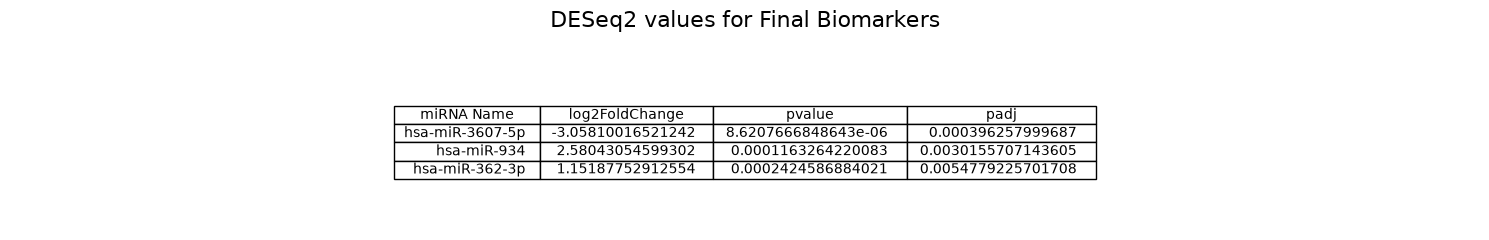

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# Use final_biomarkers_df directly
# Reset index to include 'Unnamed: 0' as a column in the table
df_temp = final_biomarkers_df.reset_index()

# Select only the relevant columns: miRNA name, log2FoldChange, pvalue, and padj
df_to_display = df_temp[['cleaned_mirna_name', 'log2FoldChange', 'pvalue', 'padj']]

# Rename 'cleaned_mirna_name' to 'miRNA Name' for better presentation
df_to_display = df_to_display.rename(columns={'cleaned_mirna_name': 'miRNA Name'})

# Create figure
# Adjust figsize dynamically based on the number of rows in the DataFrame and number of columns
fig, ax = plt.subplots(figsize=(15, len(df_to_display)*0.5 + 1))
ax.axis('off')

# Add a title for better presentation
ax.set_title('DESeq2 values for Final Biomarkers', loc='center', fontsize=16, pad=20)

# Create table
table = ax.table(
    cellText=df_to_display.values,
    colLabels=df_to_display.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

# Automatically adjust column widths for better presentation
table.auto_set_column_width(col=list(range(len(df_to_display.columns))))

# Ensure tight layout to prevent labels from overlapping
plt.tight_layout()

# Display the plot
plt.show()


plt.close()


# targetscan


In [ ]:
d3 = pd.read_excel(r"f:\downloads microsodt\TargetScan8.0__miR-3607-3p.Human.predicted_targets.xlsx")


genes = ["CHICH1", "P2RY10", "MOSPD1",  "PAGE5", "ZNF711", "GAGE12B", "DCAF6", "PEG3"]
genes2 = ["SH2D1A",  "NLRP7",  "FGF2"]

# Filter to only include rows where 'Target gene' is in the genes list
d3_filtered = d3[d3['Target gene'].isin(genes)]

display(d3_filtered)


,Target gene,Representative transcript,Gene name,3P-seq tags + 5,Total sites,8mer sites,7mer-m8 sites,7mer-A1 sites,6mer sites,Representative miRNA,Predicted occupancy (low miRNA),Predicted occupancy (high miRNA),Predicted occupancy (transfected miRNA),Cumulative weighted context++ score,Total context++ score,Aggregate PCT\n
37,MOSPD1,ENST00000370783.3,motile sperm domain containing 1,83,3,2,0,1,1,hsa-miR-3607-3p,NaN,NaN,NaN,-0.46,-0.71,N/A\n
57,P2RY10,ENST00000171757.2,"purinergic receptor P2Y, G-protein coupled, 10",5,1,1,0,0,0,hsa-miR-3607-3p,NaN,NaN,NaN,-0.41,-0.41,N/A\n
70,PAGE5,ENST00000374952.1,"P antigen family, member 5 (prostate associated)",5,1,0,1,0,0,hsa-miR-3607-3p,NaN,NaN,NaN,-0.39,-0.39,N/A\n
88,GAGE12B,ENST00000361446.5,G antigen 12B,5,1,0,1,0,0,hsa-miR-3607-3p,NaN,NaN,NaN,-0.38,-0.38,N/A\n
92,ZNF711,ENST00000360700.4,zinc finger protein 711,5614,2,0,1,1,0,hsa-miR-3607-3p,NaN,NaN,NaN,-0.38,-0.38,N/A\n
95,DCAF6,ENST00000367843.3,DDB1 and CUL4 associated factor 6,834,1,1,0,0,0,hsa-miR-3607-3p,NaN,NaN,NaN,-0.37,-0.38,N/A\n
108,PEG3,ENST00000423103.2,paternally expressed 3,5,3,1,1,1,1,hsa-miR-3607-3p,NaN,NaN,NaN,-0.36,-0.36,N/A\n


All unique target genes in d3:
<StringArray>
[ 'VPS13A',    'GMFB',    'FMO2',  'UBXN2B',   'PDE4D',    'FRG1',  'FAM65A',
    'ARSJ',   'CLOCK',  'KCNIP4',
 ...
  'ANGPT4',    'FZD8',   'LAMA4',   'IPO11', 'GDAP1L1',   'PRMT7',  'SEC23B',
   'EPHX2', 'SLC16A3',    'MCM5']
Length: 4856, dtype: str

Results containing 'CHICH':


,Target gene,Representative transcript,Gene name,3P-seq tags + 5,Total sites,8mer sites,7mer-m8 sites,7mer-A1 sites,6mer sites,Representative miRNA,Predicted occupancy (low miRNA),Predicted occupancy (high miRNA),Predicted occupancy (transfected miRNA),Cumulative weighted context++ score,Total context++ score,Aggregate PCT\n



First 20 target genes:
['VPS13A', 'GMFB', 'FMO2', 'UBXN2B', 'PDE4D', 'FRG1', 'FAM65A', 'ARSJ', 'CLOCK', 'KCNIP4', 'DBF4', 'QPCT', 'KRTAP4-6', 'ACTL7B', 'KCNJ6', 'HOMER1', 'HAUS1', 'TPO', 'HIATL1', 'IGFBP7']


In [65]:
d5 = pd.read_excel(r"F:\downloads microsodt\TargetScan8.0__miR-3607-5p.Human.predicted_targets.xlsx")


genes = ["CHICH1", "P2RY10", "MOSPD1",  "PAGE5", "ZNF711", "GAGE12B", "DCAF6", "PEG3"]
genes2 = ["SH2D1A",  "NLRP7",  "FGF2"]


# Filter to only include rows where 'Target gene' is in the genes list
d5_filtered = d5[d5['Target gene'].isin(genes2)]

display(d5_filtered)


,Target gene,Representative transcript,Gene name,3P-seq tags + 5,Total sites,8mer sites,7mer-m8 sites,7mer-A1 sites,6mer sites,Representative miRNA,Predicted occupancy (low miRNA),Predicted occupancy (high miRNA),Predicted occupancy (transfected miRNA),Cumulative weighted context++ score,Total context++ score,Aggregate PCT\n
26,NLRP7,ENST00000448121.2,"NLR family, pyrin domain containing 7",5,2,1,1,0,0,hsa-miR-3607-5p,NaN,NaN,NaN,-0.43,-0.43,N/A\n
42,FGF2,ENST00000264498.3,fibroblast growth factor 2 (basic),123,4,2,1,1,0,hsa-miR-3607-5p,NaN,NaN,NaN,-0.39,-0.53,N/A\n
60,SH2D1A,ENST00000371139.4,SH2 domain containing 1A,5,1,1,0,0,0,hsa-miR-3607-5p,NaN,NaN,NaN,-0.36,-0.36,N/A\n


In [64]:
d4 = pd.read_excel(r"F:\downloads microsodt\TargetScan8.0__miR-4419a_4510_6127_6129_6130_6133.Human.predicted_targets.xlsx")

genes3 = [
    "KLK4", "C20orf96", "POU2AF1", "WDTC1", "IL2RG", "LASP1", "ZNF703",
    "RSPO4", "PIANP"
]

# Filter directly using the 'Gene name' column or 'Target gene' column
# (Check which column actually contains the gene names)
d4_filtered = d4[d4['Target gene'].isin(genes3)]

display(d4_filtered)

,Target gene,Representative transcript,Gene name,3P-seq tags + 5,Total sites,8mer sites,7mer-m8 sites,7mer-A1 sites,6mer sites,Representative miRNA,Predicted occupancy (low miRNA),Predicted occupancy (high miRNA),Predicted occupancy (transfected miRNA),Cumulative weighted context++ score,Total context++ score,Aggregate PCT\n
0,KLK4,ENST00000324041.1,kallikrein-related peptidase 4,5,10,10,0,0,0,hsa-miR-6133,NaN,NaN,NaN,-3.72,-3.72,N/A\n
5,POU2AF1,ENST00000393067.3,POU class 2 associating factor 1,19,8,1,7,0,2,hsa-miR-6127,NaN,NaN,NaN,-2.33,-2.33,N/A\n
6,C20orf96,ENST00000382369.5,chromosome 20 open reading frame 96,257,6,0,6,0,2,hsa-miR-6127,NaN,NaN,NaN,-2.12,-2.12,N/A\n
8,WDTC1,ENST00000319394.3,WD and tetratricopeptide repeats 1,137,8,1,6,1,1,hsa-miR-6127,NaN,NaN,NaN,-1.36,-1.45,N/A\n
10,IL2RG,ENST00000374202.2,"interleukin 2 receptor, gamma",10,2,1,1,0,1,hsa-miR-4510,NaN,NaN,NaN,-1.17,-1.17,N/A\n
16,LASP1,ENST00000318008.6,LIM and SH3 protein 1,552,7,1,6,0,1,hsa-miR-6127,NaN,NaN,NaN,-1.07,-1.11,N/A\n
23,ZNF703,ENST00000331569.4,zinc finger protein 703,1557,7,0,7,0,3,hsa-miR-6127,NaN,NaN,NaN,-0.99,-1.48,N/A\n
32,RSPO4,ENST00000217260.4,R-spondin 4,5,4,0,4,0,0,hsa-miR-6127,NaN,NaN,NaN,-0.93,-0.93,N/A\n
46,PIANP,ENST00000534837.1,PILR alpha associated neural protein,8,3,1,2,0,2,hsa-miR-6127,NaN,NaN,NaN,-0.85,-0.85,N/A\n
